# Important: Download MIMIC-IV and MIMIC-IV-ED from physionet

Please read [clinicnumrobbench/data_creation/README.md](README.md) file to download and set up properly the data folder structure

# Set up working folder

In [1]:
import os
import sys

# Get the working directory and add project root to path
working_dir = '/Users/vuong/Downloads/research/repos/ClinicNumRobBench'
os.chdir(working_dir)
sys.path.append(working_dir)

print(f"Current working directory: {os.getcwd()}")
print(f"Project root added to path: {working_dir}")

Current working directory: /Users/vuong/Downloads/research/repos/ClinicNumRobBench
Project root added to path: /Users/vuong/Downloads/research/repos/ClinicNumRobBench


In [2]:
# Default values
RANDOM_STATE = 42

# Loading data

In [3]:
mimic_iv_path = "data/physionet/physionet.org/files/mimiciv/3.1"
out_sample_path = "data/mimiciv/mimic4ed/200_sampled.csv"
mimic_iv_ed_path = "data/physionet/physionet.org/files/mimic-iv-ed/2.2/ed"

In [4]:
# check if existing vitalsign.csv, if not, unzip
import subprocess

file="vitalsign"
if not os.path.exists(f"{mimic_iv_ed_path}/vitalsign.csv"):
    subprocess.run(['gunzip', '-k', f"{mimic_iv_ed_path}/{file}.csv.gz"])
    print(f"Unziped the mimic_iv_ed {file} file")
else:
    print(f"Existed the mimic_iv_ed {file} file")

Existed the mimic_iv_ed vitalsign file


In [5]:
import pandas as pd

vitalsign_path = os.path.join(mimic_iv_ed_path, f'{file}.csv')
vitalsign_df = pd.read_csv(vitalsign_path)
# drop the rhythm column and rows with missing values
vitalsign_df = vitalsign_df.drop('rhythm', axis=1).dropna()
# convert charttime to datetime column
vitalsign_df['charttime'] = pd.to_datetime(vitalsign_df['charttime'], format="%Y-%m-%d %H:%M:%S")
vitalsign_df
vitalsign_df.sort_values(by='subject_id')

,subject_id,stay_id,charttime,temperature,heartrate,resprate,o2sat,sbp,dbp,pain
6,10000032,32952584,2180-07-22 19:47:00,98.2,85.0,18.0,98.0,81.0,38.0,0
7,10000032,33258284,2180-05-06 23:04:00,97.7,79.0,16.0,98.0,107.0,60.0,0
10,10000032,38112554,2180-06-26 18:42:00,97.9,76.0,18.0,95.0,95.0,64.0,5
16,10000032,39399961,2180-07-23 09:28:00,98.1,86.0,18.0,94.0,93.0,54.0,uta
21,10000032,39399961,2180-07-23 11:51:00,99.0,93.0,16.0,95.0,84.0,40.0,asleep
...,...,...,...,...,...,...,...,...,...,...
1564594,19999828,30712109,2147-07-18 09:01:00,98.4,67.0,18.0,99.0,95.0,58.0,8
1564599,19999828,32917002,2149-01-08 09:12:00,96.6,112.0,18.0,100.0,110.0,82.0,4
1564588,19999828,30712109,2147-07-17 17:19:00,98.1,83.0,18.0,100.0,107.0,75.0,8
1564592,19999828,30712109,2147-07-18 04:28:00,99.4,65.0,18.0,99.0,90.0,60.0,6


In [6]:
mimic_iv_core_path = os.path.join(mimic_iv_path, 'core')
mimic_iv_hosp_path = os.path.join(mimic_iv_path , 'hosp')   
mimic_iv_icu_path = os.path.join(mimic_iv_path, 'icu')
mimic_iv_ed_path = os.path.join(mimic_iv_path, 'ed')

icu_filename_dict = {"chartevents":"chartevents.csv","datetimeevents":"datetimeevents.csv","d_items":"d_items.csv","icustays":"icustays.csv","inputevents":"inputevents.csv","outputevents":"outputevents.csv","procedureevents":"procedureevents.csv"}
core_filename_dict = {"patients":"patients.csv", "admissions":"admissions.csv", "transfers":"transfers.csv"}
hosp_filename_dict = {"d_hcpcs":"d_hcpcs.csv","d_icd_diagnoses":"d_icd_diagnoses.csv","d_labitems":"d_labitems.csv","emar":"emar.csv","hcpcsevents":"hcpcsevents.csv","microbiologyevents":"microbiologyevents.csv","poe":"poe.csv","prescriptions":"prescriptions.csv","services":"services.csv","diagnoses_icd":"diagnoses_icd.csv","d_icd_procedures":"d_icd_procedures.csv","drgcodes":"drgcodes.csv","emar_detail":"emar_detail.csv","labevents":"labevents.csv","pharmacy":"pharmacy.csv","poe_detail":"poe_detail.csv","procedures_icd":"procedures_icd.csv"}
ed_filename_dict = {'diagnosis':'diagnosis.csv', 'edstays':'edstays.csv',  'medrecon':'medrecon.csv',  'pyxis':'pyxis.csv',  'triage':'triage.csv',  'vitalsign':'vitalsign.csv'}

In [7]:
# check if existing file, if not, unzip
import subprocess

file=icu_filename_dict['inputevents']
if not os.path.exists(f"{mimic_iv_icu_path}/{file}"):
    subprocess.run(['gunzip', '-k', f"{mimic_iv_icu_path}/{file}.gz"])
    print(f"Unziped the mimic_iv_icu {file} file")
else:
    print(f"Existed the mimic_iv_icu {file} file")

Existed the mimic_iv_icu inputevents.csv file


In [8]:
df_path = os.path.join(mimic_iv_icu_path, icu_filename_dict['inputevents'])
df = pd.read_csv(df_path).head()
df.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'caregiver_id', 'starttime',
       'endtime', 'storetime', 'itemid', 'amount', 'amountuom', 'rate',
       'rateuom', 'orderid', 'linkorderid', 'ordercategoryname',
       'secondaryordercategoryname', 'ordercomponenttypedescription',
       'ordercategorydescription', 'patientweight', 'totalamount',
       'totalamountuom', 'isopenbag', 'continueinnextdept',
       'statusdescription', 'originalamount', 'originalrate'],
      dtype='str')

In [9]:
# check if existing file, if not, unzip
import subprocess

file=core_filename_dict['patients']
if not os.path.exists(f"{mimic_iv_hosp_path}/{file}"):
    subprocess.run(['gunzip', '-k', f"{mimic_iv_hosp_path}/{file}.gz"])
    print(f"Unziped the mimic_iv_hosp {file} file")
else:
    print(f"Existed the mimic_iv_hosp {file} file")

Existed the mimic_iv_hosp patients.csv file


In [10]:
patients_path = os.path.join(mimic_iv_hosp_path, core_filename_dict['patients'])
patients_df = pd.read_csv(patients_path)
patients_df['dod'] = pd.to_datetime(patients_df['dod'])
patients_df

,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10000032,F,52,2180,2014 - 2016,2180-09-09
1,10000048,F,23,2126,2008 - 2010,NaT
2,10000058,F,33,2168,2020 - 2022,NaT
3,10000068,F,19,2160,2008 - 2010,NaT
4,10000084,M,72,2160,2017 - 2019,2161-02-13
...,...,...,...,...,...,...
364622,19999828,F,46,2147,2017 - 2019,NaT
364623,19999829,F,28,2186,2008 - 2010,NaT
364624,19999840,M,58,2164,2008 - 2010,2164-09-17
364625,19999914,F,49,2158,2017 - 2019,NaT


In [11]:
# check if existing file, if not, unzip
import subprocess

file=icu_filename_dict['icustays']
if not os.path.exists(f"{mimic_iv_icu_path}/{file}"):
    subprocess.run(['gunzip', '-k', f"{mimic_iv_icu_path}/{file}.gz"])
    print(f"Unziped the mimic_iv_icu {file} file")
else:
    print(f"Existed the mimic_iv_icu {file} file")

Existed the mimic_iv_icu icustays.csv file


In [12]:
icustays_path = os.path.join(mimic_iv_icu_path, icu_filename_dict['icustays'])
try:
    df_icustays = pd.read_csv(icustays_path)
except FileNotFoundError:
    os.system("gzip -dk " + f'{icustays_path}.gz')
    df_icustays = pd.read_csv(icustays_path)
df_icustays['intime'] = pd.to_datetime(df_icustays['intime'])
df_icustays

,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los
0,10000032,29079034,39553978,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2180-07-23 14:00:00,2180-07-23 23:50:47,0.410266
1,10000690,25860671,37081114,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2150-11-02 19:37:00,2150-11-06 17:03:17,3.893252
2,10000980,26913865,39765666,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2189-06-27 08:42:00,2189-06-27 20:38:27,0.497535
3,10001217,24597018,37067082,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2157-11-20 19:18:02,2157-11-21 22:08:00,1.118032
4,10001217,27703517,34592300,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2157-12-19 15:42:24,2157-12-20 14:27:41,0.948113
...,...,...,...,...,...,...,...,...
94453,19999442,26785317,32336619,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2148-11-19 14:23:43,2148-11-26 13:12:15,6.950370
94454,19999625,25304202,31070865,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2139-10-10 19:18:00,2139-10-11 18:21:28,0.960741
94455,19999828,25744818,36075953,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2149-01-08 18:12:00,2149-01-10 13:11:02,1.790995
94456,19999840,21033226,38978960,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2164-09-12 09:26:28,2164-09-17 16:35:15,5.297766


## Merge data

Use columns:
- ED: all in table vitalsign
- ICU: 'subject_id', 'anchor_age', 'gender', 'anchor_year','dod'
- Patients: 'subject_id','intime'

In [13]:
df = pd.merge(vitalsign_df, patients_df[['subject_id', 'anchor_age', 'gender', 'anchor_year','dod']], on = ['subject_id'], how='inner')
df = pd.merge(df,df_icustays[['subject_id','intime']], on = ['subject_id'], how='inner')

df['in_year'] = df['intime'].dt.year
df['age'] = df['in_year'] - df['anchor_year'] + df['anchor_age']
df.drop(columns=['intime', 'in_year', 'dod', 'anchor_year', 'anchor_age'], inplace=True)
df.sort_values(by='subject_id')

,subject_id,stay_id,charttime,temperature,heartrate,resprate,o2sat,sbp,dbp,pain,gender,age
0,10000032,32952584,2180-07-22 19:47:00,98.2,85.0,18.0,98.0,81.0,38.0,0,F,52
1,10000032,33258284,2180-05-06 23:04:00,97.7,79.0,16.0,98.0,107.0,60.0,0,F,52
2,10000032,38112554,2180-06-26 18:42:00,97.9,76.0,18.0,95.0,95.0,64.0,5,F,52
3,10000032,39399961,2180-07-23 09:28:00,98.1,86.0,18.0,94.0,93.0,54.0,uta,F,52
4,10000032,39399961,2180-07-23 11:51:00,99.0,93.0,16.0,95.0,84.0,40.0,asleep,F,52
...,...,...,...,...,...,...,...,...,...,...,...,...
545066,19999442,30337261,2149-09-07 23:10:00,98.0,74.0,16.0,100.0,120.0,82.0,0,M,43
545068,19999828,30712109,2147-07-18 04:28:00,99.4,65.0,18.0,99.0,90.0,60.0,6,F,48
545069,19999828,30712109,2147-07-18 09:01:00,98.4,67.0,18.0,99.0,95.0,58.0,8,F,48
545067,19999828,30712109,2147-07-17 17:19:00,98.1,83.0,18.0,100.0,107.0,75.0,8,F,48


# Analyze data and Sampling

## Filter missing `pain` value

In [14]:
import re
df = df[df['pain'].map(lambda x: x.strip()!='0' and len(x.strip())>0 and bool(re.search(r'[\d\w]+', x.strip())))]
df

,subject_id,stay_id,charttime,temperature,heartrate,resprate,o2sat,sbp,dbp,pain,gender,age
2,10000032,38112554,2180-06-26 18:42:00,97.9,76.0,18.0,95.0,95.0,64.0,5,F,52
3,10000032,39399961,2180-07-23 09:28:00,98.1,86.0,18.0,94.0,93.0,54.0,uta,F,52
4,10000032,39399961,2180-07-23 11:51:00,99.0,93.0,16.0,95.0,84.0,40.0,asleep,F,52
15,10000980,33706525,2190-09-28 15:06:00,98.2,66.0,18.0,99.0,185.0,97.0,5,F,76
16,10000980,33706525,2190-09-28 16:17:00,98.2,70.0,18.0,99.0,177.0,92.0,4,F,76
...,...,...,...,...,...,...,...,...,...,...,...,...
545065,19999287,37929752,2197-08-03 22:51:00,98.4,100.0,15.0,96.0,126.0,54.0,3,F,77
545067,19999828,30712109,2147-07-17 17:19:00,98.1,83.0,18.0,100.0,107.0,75.0,8,F,48
545068,19999828,30712109,2147-07-18 04:28:00,99.4,65.0,18.0,99.0,90.0,60.0,6,F,48
545069,19999828,30712109,2147-07-18 09:01:00,98.4,67.0,18.0,99.0,95.0,58.0,8,F,48


## filter out subjects with too many or too few records

In [15]:
upper_threshold_records = 50
lower_threshold_records = 1

# Count the number of records per subject_id
subject_counts = df.groupby('subject_id').size()

# Filter out subjects with too many or too few records
df = df[df['subject_id'].isin(subject_counts[subject_counts.map(lambda x: lower_threshold_records<=x<=upper_threshold_records)].index)]
subject_counts = df.groupby('subject_id').size()
df.sort_values(by='subject_id')

,subject_id,stay_id,charttime,temperature,heartrate,resprate,o2sat,sbp,dbp,pain,gender,age
2,10000032,38112554,2180-06-26 18:42:00,97.9,76.0,18.0,95.0,95.0,64.0,5,F,52
3,10000032,39399961,2180-07-23 09:28:00,98.1,86.0,18.0,94.0,93.0,54.0,uta,F,52
4,10000032,39399961,2180-07-23 11:51:00,99.0,93.0,16.0,95.0,84.0,40.0,asleep,F,52
15,10000980,33706525,2190-09-28 15:06:00,98.2,66.0,18.0,99.0,185.0,97.0,5,F,76
16,10000980,33706525,2190-09-28 16:17:00,98.2,70.0,18.0,99.0,177.0,92.0,4,F,76
...,...,...,...,...,...,...,...,...,...,...,...,...
545064,19999287,37929752,2197-08-03 22:51:00,98.4,100.0,15.0,96.0,126.0,54.0,3,F,77
545068,19999828,30712109,2147-07-18 04:28:00,99.4,65.0,18.0,99.0,90.0,60.0,6,F,48
545069,19999828,30712109,2147-07-18 09:01:00,98.4,67.0,18.0,99.0,95.0,58.0,8,F,48
545067,19999828,30712109,2147-07-17 17:19:00,98.1,83.0,18.0,100.0,107.0,75.0,8,F,48


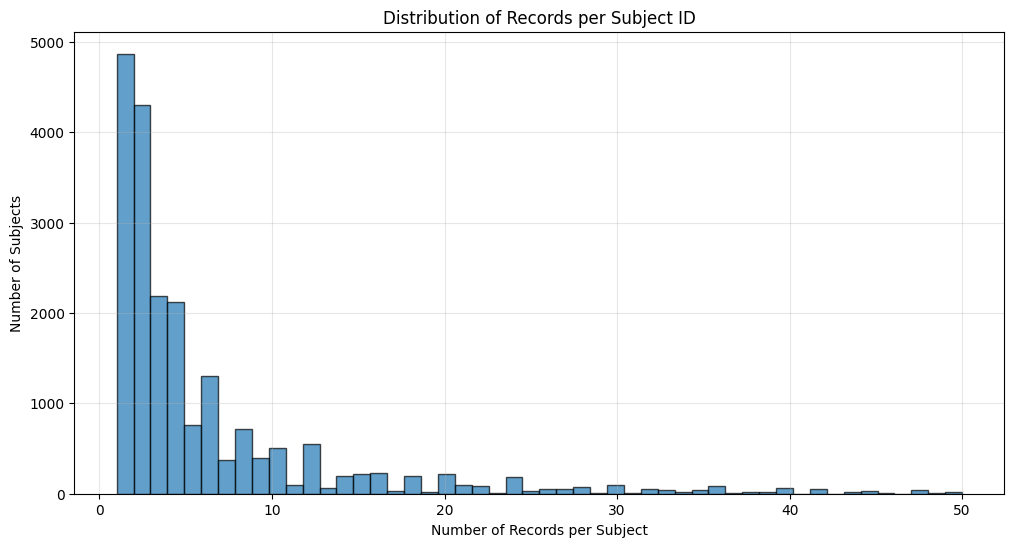

Total number of subjects: 20581
Average records per subject: 5.94
Median records per subject: 3.00
Min records per subject: 1
Max records per subject: 50


In [16]:
import matplotlib.pyplot as plt

# Create a histogram/column chart showing the distribution of record counts
plt.figure(figsize=(12, 6))
plt.hist(subject_counts.values, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Number of Records per Subject')
plt.ylabel('Number of Subjects')
plt.title('Distribution of Records per Subject ID')
plt.grid(True, alpha=0.3)
plt.show()

# Display summary statistics
print(f"Total number of subjects: {len(subject_counts)}")
print(f"Average records per subject: {subject_counts.mean():.2f}")
print(f"Median records per subject: {subject_counts.median():.2f}")
print(f"Min records per subject: {subject_counts.min()}")
print(f"Max records per subject: {subject_counts.max()}")


## Filter based on [original paper](https://github.com/nliulab/mimic4ed-benchmark/blob/main/Benchmark_scripts/data_general_processing.ipynb)

In [17]:
# Filter out patients younger than 18 years old
df = df[df['age']>=18]

# outlier detection
from clinicnumrobbench.data_creation.mimiciv_ed.helpers import *
vitals_valid_range = {
    'temperature': {'outlier_low': 14.2, 'valid_low': 26, 'valid_high': 45, 'outlier_high':47},
    'heartrate': {'outlier_low': 0, 'valid_low': 0, 'valid_high': 350, 'outlier_high':390},
    'resprate': {'outlier_low': 0, 'valid_low': 0, 'valid_high': 300, 'outlier_high':330},
    'o2sat': {'outlier_low': 0, 'valid_low': 0, 'valid_high': 100, 'outlier_high':150},
    'sbp': {'outlier_low': 0, 'valid_low': 0, 'valid_high': 375, 'outlier_high':375},
    'dbp': {'outlier_low': 0, 'valid_low': 0, 'valid_high': 375, 'outlier_high':375},
    'pain': {'outlier_low': 0, 'valid_low': 0, 'valid_high': 10, 'outlier_high':10},   
}
df = convert_temp_to_celcius(df)
display_outliers_count(df, vitals_valid_range)

,variable,< outlier_low,"[outlier_low, valid_low)","[valid_low, valid_high]","(valid_high, outlier_high]",> outlier_high


In [18]:
df = remove_outliers(df, vitals_valid_range)
df

,subject_id,stay_id,charttime,temperature,heartrate,resprate,o2sat,sbp,dbp,pain,gender,age
2,10000032,38112554,2180-06-26 18:42:00,97.9,76.0,18.0,95.0,95.0,64.0,5,F,52
3,10000032,39399961,2180-07-23 09:28:00,98.1,86.0,18.0,94.0,93.0,54.0,uta,F,52
4,10000032,39399961,2180-07-23 11:51:00,99.0,93.0,16.0,95.0,84.0,40.0,asleep,F,52
15,10000980,33706525,2190-09-28 15:06:00,98.2,66.0,18.0,99.0,185.0,97.0,5,F,76
16,10000980,33706525,2190-09-28 16:17:00,98.2,70.0,18.0,99.0,177.0,92.0,4,F,76
...,...,...,...,...,...,...,...,...,...,...,...,...
545065,19999287,37929752,2197-08-03 22:51:00,98.4,100.0,15.0,96.0,126.0,54.0,3,F,77
545067,19999828,30712109,2147-07-17 17:19:00,98.1,83.0,18.0,100.0,107.0,75.0,8,F,48
545068,19999828,30712109,2147-07-18 04:28:00,99.4,65.0,18.0,99.0,90.0,60.0,6,F,48
545069,19999828,30712109,2147-07-18 09:01:00,98.4,67.0,18.0,99.0,95.0,58.0,8,F,48


In [19]:
df.drop_duplicates(subset=df.columns.drop('age'), inplace=True, keep='first')
df

,subject_id,stay_id,charttime,temperature,heartrate,resprate,o2sat,sbp,dbp,pain,gender,age
2,10000032,38112554,2180-06-26 18:42:00,97.9,76.0,18.0,95.0,95.0,64.0,5,F,52
3,10000032,39399961,2180-07-23 09:28:00,98.1,86.0,18.0,94.0,93.0,54.0,uta,F,52
4,10000032,39399961,2180-07-23 11:51:00,99.0,93.0,16.0,95.0,84.0,40.0,asleep,F,52
15,10000980,33706525,2190-09-28 15:06:00,98.2,66.0,18.0,99.0,185.0,97.0,5,F,76
16,10000980,33706525,2190-09-28 16:17:00,98.2,70.0,18.0,99.0,177.0,92.0,4,F,76
...,...,...,...,...,...,...,...,...,...,...,...,...
545064,19999287,37929752,2197-08-03 22:51:00,98.4,100.0,15.0,96.0,126.0,54.0,3,F,77
545067,19999828,30712109,2147-07-17 17:19:00,98.1,83.0,18.0,100.0,107.0,75.0,8,F,48
545068,19999828,30712109,2147-07-18 04:28:00,99.4,65.0,18.0,99.0,90.0,60.0,6,F,48
545069,19999828,30712109,2147-07-18 09:01:00,98.4,67.0,18.0,99.0,95.0,58.0,8,F,48


In [20]:
df['subject_id'].nunique()

20581

## Sampling data

### age categories

In [21]:
# Create age categories based on life stages
# follow by https://www.cms.gov/data-research/statistics-trends-and-reports/national-health-expenditure-data/age-and-sex
def categorize_age(age):
    if age <= 18:
        return 'pediatric'
    elif age <= 44:
        return 'young_adult'
    elif age <= 64:
        return 'middle_age'
    elif age <= 84:
        return 'older_adult'
    else:
        return 'elderly'

df['age_cate'] = df['age'].apply(categorize_age)
df['age_cate'].value_counts()

age_cate
middle_age     27772
older_adult    26910
young_adult    11702
elderly         8351
pediatric         72
Name: count, dtype: int64

### vitalsign count

In [22]:
# Count vital signs per subject and categorize by frequency
subject_counts = df['subject_id'].value_counts()

# Categorize subjects by number of vital sign records
def categorize_vitals_count(count):
    if count <= 5:
        return '1-5'
    elif count <= 20:
        return '5-20'
    else:
        return '20-50'

# Apply categorization
vitals_categories = subject_counts.apply(categorize_vitals_count)

# Add vitals count category column to dataframe
df['vitals_count'] = df['subject_id'].map(subject_counts)
df['vitals_count_category'] = df['vitals_count'].apply(categorize_vitals_count)

# Display distribution of subjects by vital signs count categories
print("Distribution of subjects by vital signs count:")
print(vitals_categories.value_counts())
print(df['vitals_count_category'].value_counts())

# Display original counts for reference
print("\nDetailed subject vital signs counts:")
df

Distribution of subjects by vital signs count:
count
1-5      16872
5-20      3509
20-50      200
Name: count, dtype: int64
vitals_count_category
1-5      37221
5-20     31930
20-50     5656
Name: count, dtype: int64

Detailed subject vital signs counts:


,subject_id,stay_id,charttime,temperature,heartrate,resprate,o2sat,sbp,dbp,pain,gender,age,age_cate,vitals_count,vitals_count_category
2,10000032,38112554,2180-06-26 18:42:00,97.9,76.0,18.0,95.0,95.0,64.0,5,F,52,middle_age,3,1-5
3,10000032,39399961,2180-07-23 09:28:00,98.1,86.0,18.0,94.0,93.0,54.0,uta,F,52,middle_age,3,1-5
4,10000032,39399961,2180-07-23 11:51:00,99.0,93.0,16.0,95.0,84.0,40.0,asleep,F,52,middle_age,3,1-5
15,10000980,33706525,2190-09-28 15:06:00,98.2,66.0,18.0,99.0,185.0,97.0,5,F,76,older_adult,2,1-5
16,10000980,33706525,2190-09-28 16:17:00,98.2,70.0,18.0,99.0,177.0,92.0,4,F,76,older_adult,2,1-5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
545064,19999287,37929752,2197-08-03 22:51:00,98.4,100.0,15.0,96.0,126.0,54.0,3,F,77,older_adult,1,1-5
545067,19999828,30712109,2147-07-17 17:19:00,98.1,83.0,18.0,100.0,107.0,75.0,8,F,48,middle_age,4,1-5
545068,19999828,30712109,2147-07-18 04:28:00,99.4,65.0,18.0,99.0,90.0,60.0,6,F,48,middle_age,4,1-5
545069,19999828,30712109,2147-07-18 09:01:00,98.4,67.0,18.0,99.0,95.0,58.0,8,F,48,middle_age,4,1-5


### gender

In [23]:
df['gender'].value_counts()

gender
F    37949
M    36858
Name: count, dtype: int64

### check group

In [24]:
df.groupby('subject_id').last().groupby(['vitals_count_category','gender', 'age_cate']).size()

vitals_count_category  gender  age_cate   
1-5                    F       elderly        1272
                               middle_age     2325
                               older_adult    3165
                               pediatric        19
                               young_adult    1077
                       M       elderly         911
                               middle_age     3185
                               older_adult    3633
                               pediatric        15
                               young_adult    1270
20-50                  F       elderly           8
                               middle_age       53
                               older_adult      29
                               young_adult      28
                       M       elderly           2
                               middle_age       50
                               older_adult       7
                               young_adult      23
5-20                   F       elderly 

### Stratify

In [25]:
unit_subject_df = df.groupby('subject_id').last().reset_index()

In [26]:
print(unit_subject_df['vitals_count_category'].value_counts())
unit_subject_df['vitals_count_category'].value_counts(normalize=True)

vitals_count_category
1-5      16872
5-20      3509
20-50      200
Name: count, dtype: int64


vitals_count_category
1-5      0.819785
5-20     0.170497
20-50    0.009718
Name: proportion, dtype: float64

In [27]:
(unit_subject_df['vitals_count_category'].value_counts(normalize=True)*200).round().to_dict()

{'1-5': 164.0, '5-20': 34.0, '20-50': 2.0}

In [28]:
def recommended_stratified_sampling(df, target_groups=200, random_state=42):
    """
    Recommended approach: Maintain vitals_count_category proportion
    but ensure adequate representation of all age/gender combinations
    """
    weight_col = 'vitals_count_category'
    age_col = 'age_cate'
    gender_col = 'gender'
    subject_id_col = 'subject_id'
    
    # Target distribution based on original proportions
    target_distribution = (df[weight_col].value_counts(normalize=True)*200).round().astype(int).to_dict()
    
    # make sure the total number of samples is exactly 200
    total = sum(target_distribution.values())
    target_distribution['1-5'] += (200 - total)
    
    print("Target sample distribution:")
    for cat, n in target_distribution.items():
        print(f"  {cat}: {n} samples")
    
    sampled_dfs = []
    
    for vitals_cat, target_n in target_distribution.items():
        vitals_df = df[df[weight_col] == vitals_cat]
        
        # Get all gender x age_cate combinations in this vitals category
        strata = vitals_df.groupby([gender_col, age_col]).size()
        
        # Proportional allocation within this vitals category
        strata_samples = {}
        for (gender, age_cat), count in strata.items():
            proportion = count / len(vitals_df)
            strata_samples[(gender, age_cat)] = max(1, int(target_n * proportion))
        
        # Adjust if needed
        current = sum(strata_samples.values())
        if current != target_n:
            diff = target_n - current
            # Add/subtract from largest stratum
            largest = max(strata.items(), key=lambda x: x[1])[0]
            strata_samples[largest] = max(1, strata_samples[largest] + diff)
        
        # Sample from each stratum
        for (gender, age_cat), n_sample in strata_samples.items():
            mask = (
                (vitals_df[gender_col] == gender) &
                (vitals_df[age_col] == age_cat)
            )
            stratum_data = vitals_df[mask]
            
            n_sample = min(n_sample, len(stratum_data))
            if n_sample > 0:
                sampled = stratum_data.sample(n=n_sample, random_state=random_state)
                sampled_dfs.append(sampled)
    
    final_sample = pd.concat(sampled_dfs, ignore_index=True)
    
    # Validation
    print("\n=== SAMPLING VALIDATION ===")
    print(f"Total sampled: {len(final_sample)}")
    print("\nDistribution by vitals_count_category:")
    print(final_sample['vitals_count_category'].value_counts().sort_index())
    print("\nDistribution by gender:")
    print(final_sample['gender'].value_counts())
    print("\nDistribution by age_cate:")
    print(final_sample['age_cate'].value_counts())
    
    return final_sample


sampled_subjects = recommended_stratified_sampling(unit_subject_df, target_groups=200, random_state=RANDOM_STATE)['subject_id'].tolist()
sampled_df = df[df['subject_id'].isin(sampled_subjects)]
sampled_df

Target sample distribution:
  1-5: 164 samples
  5-20: 34 samples
  20-50: 2 samples

=== SAMPLING VALIDATION ===
Total sampled: 206

Distribution by vitals_count_category:
vitals_count_category
1-5      164
20-50      8
5-20      34
Name: count, dtype: int64

Distribution by gender:
gender
M    111
F     95
Name: count, dtype: int64

Distribution by age_cate:
age_cate
older_adult    81
middle_age     69
young_adult    28
elderly        25
pediatric       3
Name: count, dtype: int64


,subject_id,stay_id,charttime,temperature,heartrate,resprate,o2sat,sbp,dbp,pain,gender,age,age_cate,vitals_count,vitals_count_category
3851,10092020,37333689,2135-06-15 11:11:00,97.5,63.0,15.0,100.0,138.0,80.0,6,M,69,older_adult,1,1-5
8208,10168562,37598096,2124-07-24 18:53:00,98.5,62.0,16.0,99.0,122.0,65.0,4,F,18,pediatric,1,1-5
9024,10197727,39726422,2158-06-06 20:22:00,98.0,95.0,16.0,99.0,160.0,72.0,3,M,40,young_adult,3,1-5
9025,10197727,39726422,2158-06-06 21:43:00,102.2,112.0,18.0,98.0,172.0,79.0,5,M,40,young_adult,3,1-5
9026,10197727,39726422,2158-06-07 00:10:00,101.0,122.0,24.0,96.0,163.0,61.0,8,M,40,young_adult,3,1-5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
544347,19985757,37571161,2174-09-01 11:34:00,98.6,82.0,18.0,100.0,124.0,69.0,8,F,77,older_adult,2,1-5
544355,19986107,32928247,2171-06-23 19:24:00,97.9,101.0,20.0,99.0,149.0,79.0,5,F,55,middle_age,2,1-5
544356,19986107,32928247,2171-06-23 23:07:00,97.1,110.0,22.0,95.0,183.0,95.0,7,F,55,middle_age,2,1-5
544560,19990786,34314807,2157-07-12 14:51:00,98.5,65.0,18.0,95.0,92.0,42.0,6,M,80,older_adult,2,1-5


In [29]:
sampled_df.groupby('subject_id').last()['vitals_count_category'].value_counts()

vitals_count_category
1-5      164
5-20      34
20-50      8
Name: count, dtype: int64

In [30]:
print(sampled_df[sampled_df['heartrate']>round(sampled_df['heartrate'],0)])
sampled_df['heartrate'] = sampled_df['heartrate'].astype(int)
print(sampled_df[sampled_df['resprate']>round(sampled_df['resprate'],0)])
sampled_df['resprate'] = sampled_df['resprate'].astype(int)
print(sampled_df[sampled_df['o2sat']>round(sampled_df['o2sat'],0)])
sampled_df['o2sat'] = sampled_df['o2sat'].astype(int)
print(sampled_df[sampled_df['sbp']>round(sampled_df['sbp'],0)])
sampled_df['sbp'] = sampled_df['sbp'].astype(int)
print(sampled_df[sampled_df['dbp']>round(sampled_df['dbp'],0)])
sampled_df['dbp'] = sampled_df['dbp'].astype(int)

Empty DataFrame
Columns: [subject_id, stay_id, charttime, temperature, heartrate, resprate, o2sat, sbp, dbp, pain, gender, age, age_cate, vitals_count, vitals_count_category]
Index: []
Empty DataFrame
Columns: [subject_id, stay_id, charttime, temperature, heartrate, resprate, o2sat, sbp, dbp, pain, gender, age, age_cate, vitals_count, vitals_count_category]
Index: []
Empty DataFrame
Columns: [subject_id, stay_id, charttime, temperature, heartrate, resprate, o2sat, sbp, dbp, pain, gender, age, age_cate, vitals_count, vitals_count_category]
Index: []
Empty DataFrame
Columns: [subject_id, stay_id, charttime, temperature, heartrate, resprate, o2sat, sbp, dbp, pain, gender, age, age_cate, vitals_count, vitals_count_category]
Index: []
Empty DataFrame
Columns: [subject_id, stay_id, charttime, temperature, heartrate, resprate, o2sat, sbp, dbp, pain, gender, age, age_cate, vitals_count, vitals_count_category]
Index: []


In [31]:
sampled_df= convert_temp_to_celcius(sampled_df, use_split=False)

In [32]:
os.makedirs(os.path.dirname(out_sample_path), exist_ok=True)
sampled_df.to_csv(out_sample_path, index=False)

In [ ]:
print(f"saved sample to path: {out_sample_path}")

saved sample to path: data/mimiciv/mimic4ed/200_sampled.csv
